In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 100)

In [3]:
movies = pd.read_csv("../data/movies.csv")
ratings = pd.read_csv("../data/ratings.csv")

print("Movies shape:", movies.shape)
print("Ratings shape:", ratings.shape)

Movies shape: (10329, 3)
Ratings shape: (105339, 4)


In [4]:
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [5]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,16,4.0,1217897793
1,1,24,1.5,1217895807
2,1,32,4.0,1217896246
3,1,47,4.0,1217896556
4,1,50,4.0,1217896523


In [6]:
print("Movie columns:")
print(movies.columns.tolist())

print("\nRating columns:")
print(ratings.columns.tolist())

Movie columns:
['movieId', 'title', 'genres']

Rating columns:
['userId', 'movieId', 'rating', 'timestamp']


Checking the Missing Values

In [7]:
print("Missing values in movies:")
print(movies.isnull().sum())

print("\nMissing values in ratings:")
print(ratings.isnull().sum())

Missing values in movies:
movieId    0
title      0
genres     0
dtype: int64

Missing values in ratings:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64


Checking the duplicates

In [8]:
print("Duplicate rows in movies:", movies.duplicated().sum())
print("Duplicate rows in ratings:", ratings.duplicated().sum())

Duplicate rows in movies: 0
Duplicate rows in ratings: 0


In [9]:
print(
    "Duplicate movie IDs:",
    movies["movieId"].duplicated().sum()
)

Duplicate movie IDs: 0


Basics Statics

In [10]:
ratings.describe()

,userId,movieId,rating,timestamp
count,105339.000000,105339.000000,105339.000000,1.053390e+05
mean,364.924539,13381.312477,3.516850,1.130424e+09
std,197.486905,26170.456869,1.044872,1.802660e+08
min,1.000000,1.000000,0.500000,8.285650e+08
25%,192.000000,1073.000000,3.000000,9.711008e+08
50%,383.000000,2497.000000,3.500000,1.115154e+09
75%,557.000000,5991.000000,4.000000,1.275496e+09
max,668.000000,149532.000000,5.000000,1.452405e+09


In [11]:
print("Number of users:", ratings["userId"].nunique())
print("Number of movies rated:", ratings["movieId"].nunique())
print("Number of movies in dataset:", movies["movieId"].nunique())

Number of users: 668
Number of movies rated: 10325
Number of movies in dataset: 10329


Rating Distribution

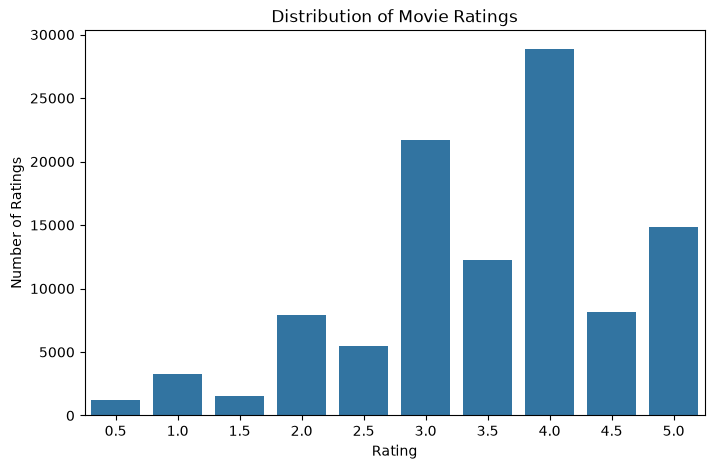

In [12]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=ratings,
    x="rating"
)

plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")
plt.show()

Most Rated Movies

In [13]:
rating_counts = (
    ratings.groupby("movieId")
    .size()
    .reset_index(name="rating_count")
)

In [14]:
movie_rating_counts = rating_counts.merge(
    movies,
    on="movieId"
)

Top 10 movies ratings

In [15]:
movie_rating_counts.sort_values(
    "rating_count",
    ascending=False
).head(10)

,movieId,rating_count,title,genres
260,296,325,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller
316,356,311,Forrest Gump (1994),Comedy|Drama|Romance|War
279,318,308,"Shawshank Redemption, The (1994)",Crime|Drama
426,480,294,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller
525,593,290,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller
230,260,273,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi
2056,2571,261,"Matrix, The (1999)",Action|Sci-Fi|Thriller
522,589,253,Terminator 2: Judgment Day (1991),Action|Sci-Fi
471,527,248,Schindler's List (1993),Drama|War
98,110,248,Braveheart (1995),Action|Drama|War


Average Movies Ratings

In [16]:
movie_avg_ratings = (
    ratings.groupby("movieId")["rating"]
    .agg(["mean", "count"])
    .reset_index()
)

movie_avg_ratings.columns = [
    "movieId",
    "average_rating",
    "rating_count"
]

movie_avg_ratings = movie_avg_ratings.merge(
    movies,
    on="movieId"
)

In [17]:
movie_avg_ratings.sort_values(
    "average_rating",
    ascending=False
).head(10)

,movieId,average_rating,rating_count,title,genres
10296,140820,5.0,1,Air (2015),Sci-Fi|Thriller
10281,139620,5.0,1,Everything's Gonna Be Great (1998),Adventure|Children|Comedy|Drama
10279,139385,5.0,1,The Revenant (2015),Adventure|Drama
412,465,5.0,1,Heaven & Earth (1993),Action|Drama|War
8878,84716,5.0,1,Castaway on the Moon (Kimssi pyoryugi) (2009),Comedy|Drama|Romance
8483,76089,5.0,1,Flesh and the Devil (1926),Drama|Romance
1854,2342,5.0,1,Hard Core Logo (1996),Comedy|Drama
2866,3621,5.0,1,Possession (1981),Drama|Horror
2824,3559,5.0,1,Limelight (1952),Comedy|Drama|Romance
2653,3340,5.0,1,Bride of the Monster (1955),Horror|Sci-Fi


In [18]:
popular_movies = movie_avg_ratings[
    movie_avg_ratings["rating_count"] >= 50
]

popular_movies.sort_values(
    "average_rating",
    ascending=False
).head(10)

,movieId,average_rating,rating_count,title,genres
279,318,4.454545,308,"Shawshank Redemption, The (1994)",Crime|Drama
744,923,4.396104,77,Citizen Kane (1941),Drama|Mystery
695,858,4.392857,210,"Godfather, The (1972)",Crime|Drama
2398,3000,4.384615,52,Princess Mononoke (Mononoke-hime) (1997),Action|Adventure|Animation|Drama|Fantasy
725,904,4.331081,74,Rear Window (1954),Mystery|Thriller
47,50,4.328947,228,"Usual Suspects, The (1995)",Crime|Mystery|Thriller
1011,1252,4.323529,68,Chinatown (1974),Crime|Film-Noir|Mystery|Thriller
922,1136,4.301948,154,Monty Python and the Holy Grail (1975),Adventure|Comedy|Fantasy
471,527,4.296371,248,Schindler's List (1993),Drama|War
729,908,4.273973,73,North by Northwest (1959),Action|Adventure|Mystery|Romance|Thriller


Genre analysis

In [19]:
genre_data = movies.copy()

genre_data["genres"] = genre_data["genres"].str.split("|")

genre_data = genre_data.explode("genres")

In [20]:
genre_counts = (
    genre_data["genres"]
    .value_counts()
)

print(genre_counts)

genres
Drama                 5220
Comedy                3515
Thriller              2187
Romance               1788
Action                1737
Crime                 1440
Adventure             1164
Horror                1001
Sci-Fi                 860
Mystery                675
Fantasy                670
Children               540
War                    503
Documentary            415
Musical                409
Animation              401
Western                235
Film-Noir              195
IMAX                   152
(no genres listed)       7
Name: count, dtype: int64


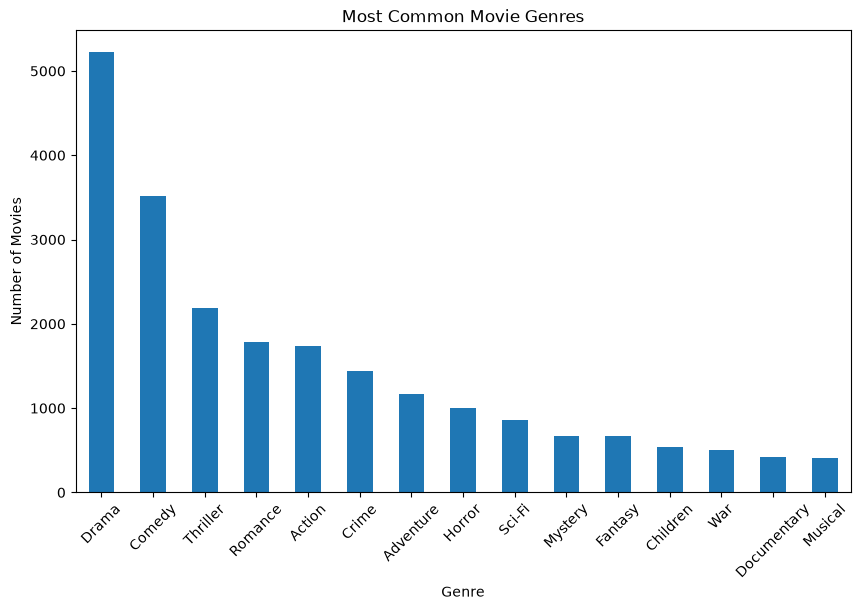

In [21]:
plt.figure(figsize=(10, 6))

genre_counts.head(15).plot(kind="bar")

plt.title("Most Common Movie Genres")
plt.xlabel("Genre")
plt.ylabel("Number of Movies")
plt.xticks(rotation=45)

plt.show()

In [22]:
user_activity = (
    ratings.groupby("userId")
    .size()
    .sort_values(ascending=False)
)

user_activity.head(10)

userId
668    5678
575    2837
458    2086
232    1421
310    1287
475    1249
128    1231
224    1182
607    1176
63     1107
dtype: int64

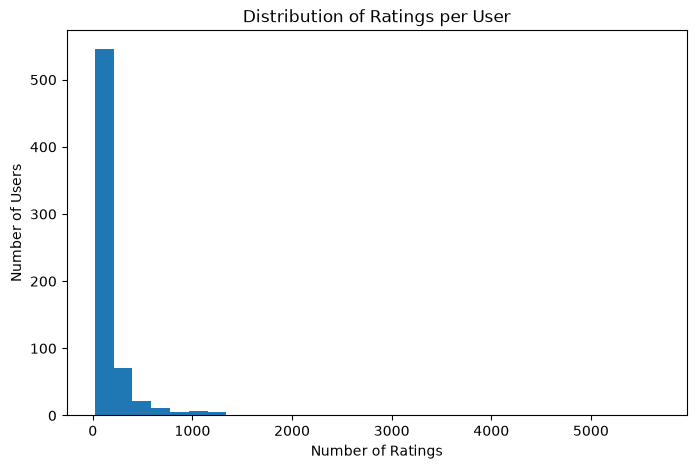

In [23]:
plt.figure(figsize=(8, 5))

plt.hist(
    user_activity,
    bins=30
)

plt.title("Distribution of Ratings per User")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Users")

plt.show()

In [24]:
data = ratings.merge(
    movies,
    on="movieId",
    how="left"
)

data.head()

,userId,movieId,rating,timestamp,title,genres
0,1,16,4.0,1217897793,Casino (1995),Crime|Drama
1,1,24,1.5,1217895807,Powder (1995),Drama|Sci-Fi
2,1,32,4.0,1217896246,Twelve Monkeys (a.k.a. 12 Monkeys) (1995),Mystery|Sci-Fi|Thriller
3,1,47,4.0,1217896556,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,4.0,1217896523,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [25]:
print("Combined dataset shape:", data.shape)
print(data.isnull().sum())

Combined dataset shape: (105339, 6)
userId       0
movieId      0
rating       0
timestamp    0
title        0
genres       0
dtype: int64
